In [14]:
import pandas as pd

df = pd.read_csv("../data/data.csv")

# Rename and parse manually
df = df.rename(columns={'time': 'datetime'})
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

df = df[['global_active_power']]
df = df.dropna()

print(df.head())

C:\Users\muham\AppData\Local\Temp\ipykernel_3788\1173043546.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datetime'] = pd.to_datetime(df['datetime'])


                     global_active_power
datetime                                
2026-04-01 00:00:00                2.580
2026-04-01 00:01:00                2.552
2026-04-01 00:02:00                2.550
2026-04-01 00:03:00                2.550
2026-04-01 00:04:00                2.554


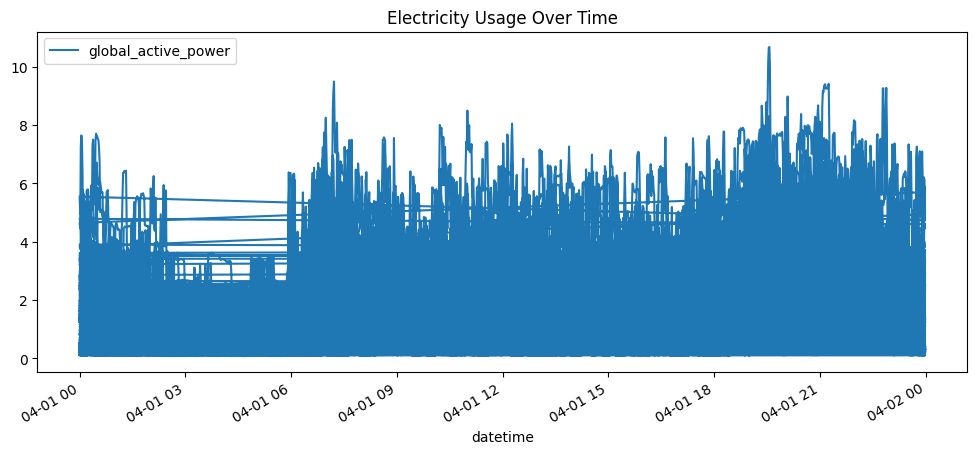

In [15]:
import matplotlib.pyplot as plt

df.plot(figsize=(12,5))
plt.title("Electricity Usage Over Time")
plt.show()

In [17]:
df = df.resample('h').mean()

In [18]:
df['hour'] = df.index.hour
df['day'] = df.index.day
df['month'] = df.index.month
df = df.dropna()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['hour', 'day', 'month']]
y = df['global_active_power']  # lowercase

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
from sklearn.metrics import mean_absolute_error

preds = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, preds))

MAE: 0.5753543665141595


In [22]:
import joblib
joblib.dump(model, "model.pkl")

['model.pkl']

In [23]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.01)
df['anomaly'] = iso.fit_predict(df[['global_active_power']])  # lowercase

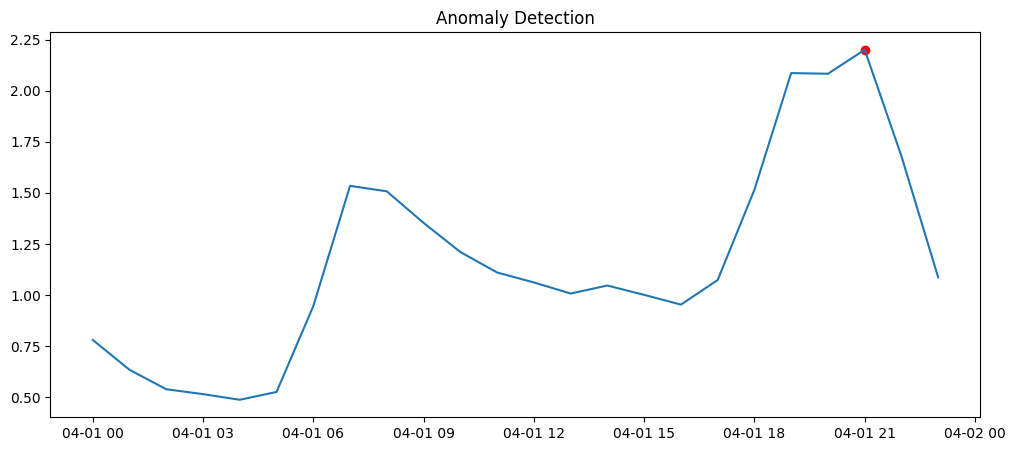

In [26]:
anomalies = df[df['anomaly'] == -1]

plt.figure(figsize=(12,5))
plt.plot(df.index, df['global_active_power'])  # lowercase
plt.scatter(anomalies.index, anomalies['global_active_power'], color='red')  # lowercase
plt.title("Anomaly Detection")
plt.show()

In [27]:
joblib.dump(iso, "anomaly.pkl")

['anomaly.pkl']